# Least Squares: Foundation of Linear Regression and Model Fitting

## Overview

**Least Squares** is one of the oldest and most fundamental optimization principles in statistics and machine learning. It provides a method to fit models to data by finding parameters that minimize the sum of squared prediction errors.

### Why Least Squares?

1. **Closed-form solution** - For linear models, we can solve exactly without iterations
2. **Geometric intuition** - Orthogonal projection onto column space of design matrix
3. **Statistical foundation** - Optimal MLE under Gaussian noise assumption
4. **Computational simplicity** - No hyperparameters (learning rate) to tune
5. **Interpretability** - Minimizes prediction errors in original units
6. **Extension foundation** - Ridge regression, Lasso, elastic net all build on least squares

### Historical Context

- **1795**: Carl Friedrich Gauss invented least squares method for fitting orbits of celestial bodies
- **1805**: Adrien-Marie Legendre independently developed and published the method
- **Modern era**: Foundation for regression, GLMs, neural networks initialization, and countless applications

---

## Section 1: Mathematical Foundations

### 1.1 Problem Statement

**Given**: 
- Data: $(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)$ where $x_i \in \mathbb{R}^d$, $y_i \in \mathbb{R}$
- Linear model: $\hat{y}_i = \theta^T x_i + \epsilon_i$ where $\epsilon_i$ is noise

**Find**: Parameters $\theta \in \mathbb{R}^d$ that minimize prediction error

### 1.2 Three Forms of Least Squares

#### **Equation Form** (single sample)

Residual for sample $i$:
$$r_i = y_i - \hat{y}_i = y_i - \theta^T x_i$$

Squared error for sample $i$:
$$e_i = r_i^2 = (y_i - \theta^T x_i)^2$$

#### **Array Form** (all samples, summation)

Sum of Squared Errors (SSE) or Residual Sum of Squares (RSS):
$$J(\theta) = \sum_{i=1}^{n} (y_i - \theta^T x_i)^2$$

Or equivalently, Mean Squared Error (MSE):
$$\text{MSE}(\theta) = \frac{1}{n}\sum_{i=1}^{n} (y_i - \theta^T x_i)^2$$

#### **Matrix Form** (compact vectorized notation)

Let $X \in \mathbb{R}^{n \times d}$ be the design matrix and $\mathbf{y} \in \mathbb{R}^n$ be the response vector:

$$J(\boldsymbol{\theta}) = \|\mathbf{y} - X\boldsymbol{\theta}\|_2^2 = (\mathbf{y} - X\boldsymbol{\theta})^T(\mathbf{y} - X\boldsymbol{\theta})$$

Or with MSE:
$$\text{MSE}(\boldsymbol{\theta}) = \frac{1}{n}\|\mathbf{y} - X\boldsymbol{\theta}\|_2^2$$

---

## Section 2: Geometric Interpretation

### 2.1 Orthogonal Projection

The least squares solution can be understood as **orthogonal projection**:

- Each column of $X$ is a direction in $\mathbb{R}^n$ space
- Column space $\text{Col}(X)$ is the subspace spanned by columns of $X$
- Optimal prediction $\hat{\mathbf{y}} = X\boldsymbol{\theta}^*$ is the point in $\text{Col}(X)$ **closest to** $\mathbf{y}$
- This occurs when residual $\mathbf{r} = \mathbf{y} - \hat{\mathbf{y}}$ is **perpendicular** to $\text{Col}(X)$

### 2.2 Normal Equations

From orthogonality condition: $X^T(\mathbf{y} - X\boldsymbol{\theta}) = 0$

$$X^T X \boldsymbol{\theta} = X^T \mathbf{y}$$

**Least Squares Solution** (assuming $X^T X$ is invertible):
$$\boxed{\boldsymbol{\theta}^* = (X^T X)^{-1} X^T \mathbf{y}}$$

The matrix $(X^T X)^{-1}X^T$ is called the **pseudoinverse** $X^+$ of $X$.

---

## Section 3: Derivation via Calculus

## Quick overview — fit a line by minimising the *squared gaps*

Given noisy points $(x_i, y_i)$, least squares chooses the line $\hat y = w x + b$ that minimises
$\sum_i (y_i - \hat y_i)^2$ — the **sum of squared vertical residuals**.

- Square (not absolute value) → smooth, differentiable, **closed-form solution** $\hat w = (X^TX)^{-1}X^Ty$.
- The picture below shows the data, the best-fit line, and the **red residuals** being squared and summed.


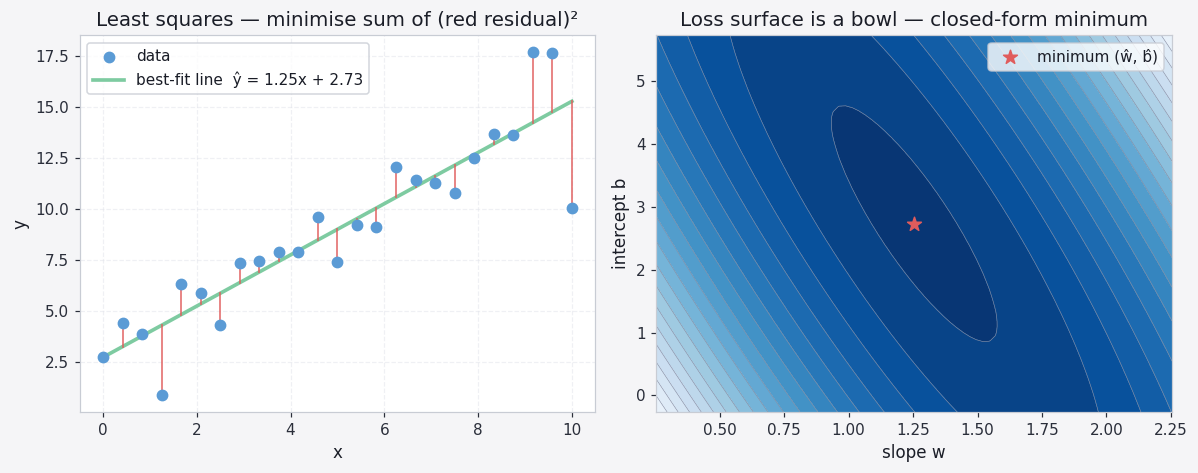

In [1]:
# (quick-overview schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':13,'axes.labelsize':11,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.default_rng(1)
x = np.linspace(0, 10, 25)
y = 1.4*x + 2.0 + rng.normal(0, 2.2, x.size)
w, b = np.polyfit(x, y, 1)
yhat = w*x + b

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

ax = axes[0]
ax.scatter(x, y, color=P[0], s=45, zorder=3, label='data')
ax.plot(x, yhat, color=P[3], lw=2.4, label=f'best-fit line  ŷ = {w:.2f}x + {b:.2f}')
for xi, yi, yhi in zip(x, y, yhat):
    ax.plot([xi, xi], [yi, yhi], color=P[1], lw=1.2, alpha=0.8)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Least squares — minimise sum of (red residual)²')
ax.legend(); ax.grid(True)

# --- right: loss surface ---
ax = axes[1]
ws = np.linspace(w-1.0, w+1.0, 80)
bs = np.linspace(b-3.0, b+3.0, 80)
W, B = np.meshgrid(ws, bs)
L = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        L[i,j] = ((y - (W[i,j]*x + B[i,j]))**2).sum()
cs = ax.contourf(W, B, L, levels=20, cmap='Blues_r')
ax.contour(W, B, L, levels=20, colors='#888fa5', linewidths=0.4)
ax.scatter([w], [b], color=P[1], s=90, marker='*', zorder=5, label='minimum (ŵ, b̂)')
ax.set_xlabel('slope w'); ax.set_ylabel('intercept b')
ax.set_title('Loss surface is a bowl — closed-form minimum')
ax.legend()
plt.tight_layout(); plt.show()


## Learning Objectives

By the end of this notebook, you will be able to:

1. **Express** the least squares objective in equation form, summation form, and matrix form, and translate between them
2. **Derive** the Normal Equation $\theta^* = (X^TX)^{-1}X^Ty$ from scratch by setting $\nabla J = 0$
3. **Prove** that least squares is the MLE under Gaussian noise — connecting optimization to probability
4. **Identify** when $(X^TX)$ is singular and know the remedies: pseudoinverse, ridge regression
5. **Compare** least squares, gradient descent, and Newton's method for linear regression on speed and applicability
6. **Apply** the Gauss-Markov theorem: least squares is BLUE even without a Gaussian assumption

> **Prerequisite**: Linear algebra (ml_000_00); likelihood and MLE (ml_000_02).
> **How to use**: Work through the derivation in Section 3 by hand before running the code. Pay special attention to the equivalence of the geometric (projection) and analytic (gradient=0) perspectives.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Symbolic derivation visualization
print("=" * 70)
print("LEAST SQUARES DERIVATION VIA CALCULUS")
print("=" * 70)

print("\n1. Start with MSE objective:")
print("   J(θ) = (1/n) * ||y - Xθ||²")
print("        = (1/n) * (y - Xθ)ᵀ(y - Xθ)")

print("\n2. Expand the product:")
print("   J(θ) = (1/n) * [yᵀy - yᵀXθ - θᵀXᵀy + θᵀXᵀXθ]")
print("        = (1/n) * [yᵀy - 2θᵀXᵀy + θᵀXᵀXθ]")
print("   (using yᵀXθ = θᵀXᵀy, both are scalars)")

print("\n3. Take gradient with respect to θ:")
print("   ∂J/∂θ = (1/n) * [-2Xᵀy + 2XᵀXθ]")
print("         = (2/n) * [XᵀXθ - Xᵀy]")

print("\n4. Set gradient to zero (at optimum):")
print("   ∂J/∂θ = 0")
print("   ⟹ XᵀXθ - Xᵀy = 0")
print("   ⟹ XᵀXθ = Xᵀy")

print("\n5. Solve for θ (Normal Equations):")
print("   θ* = (XᵀX)⁻¹Xᵀy")

print("\n6. Verify this is a minimum (not maximum):")
print("   Hessian: ∂²J/∂θ² = (2/n) * XᵀX")
print("   Since XᵀX is positive semi-definite → minimum ✓")

print("\n" + "=" * 70)

LEAST SQUARES DERIVATION VIA CALCULUS

1. Start with MSE objective:
   J(θ) = (1/n) * ||y - Xθ||²
        = (1/n) * (y - Xθ)ᵀ(y - Xθ)

2. Expand the product:
   J(θ) = (1/n) * [yᵀy - yᵀXθ - θᵀXᵀy + θᵀXᵀXθ]
        = (1/n) * [yᵀy - 2θᵀXᵀy + θᵀXᵀXθ]
   (using yᵀXθ = θᵀXᵀy, both are scalars)

3. Take gradient with respect to θ:
   ∂J/∂θ = (1/n) * [-2Xᵀy + 2XᵀXθ]
         = (2/n) * [XᵀXθ - Xᵀy]

4. Set gradient to zero (at optimum):
   ∂J/∂θ = 0
   ⟹ XᵀXθ - Xᵀy = 0
   ⟹ XᵀXθ = Xᵀy

5. Solve for θ (Normal Equations):
   θ* = (XᵀX)⁻¹Xᵀy

6. Verify this is a minimum (not maximum):
   Hessian: ∂²J/∂θ² = (2/n) * XᵀX
   Since XᵀX is positive semi-definite → minimum ✓



### 3.1 Step-by-Step Derivation

**Step 1**: Expand the MSE objective
$$J(\boldsymbol{\theta}) = \frac{1}{n}(\mathbf{y} - X\boldsymbol{\theta})^T(\mathbf{y} - X\boldsymbol{\theta})$$
$$= \frac{1}{n}[\mathbf{y}^T\mathbf{y} - 2\boldsymbol{\theta}^T X^T \mathbf{y} + \boldsymbol{\theta}^T X^T X \boldsymbol{\theta}]$$

**Step 2**: Compute gradient
$$\frac{\partial J}{\partial \boldsymbol{\theta}} = \frac{1}{n}[-2X^T\mathbf{y} + 2X^T X\boldsymbol{\theta}] = \frac{2}{n}[X^T X\boldsymbol{\theta} - X^T \mathbf{y}]$$

**Step 3**: Set gradient to zero
$$X^T X\boldsymbol{\theta} = X^T \mathbf{y}$$

**Step 4**: Solve for optimal parameters
$$\boldsymbol{\theta}^* = (X^T X)^{-1}X^T \mathbf{y}$$

**Step 5**: Verify it's a minimum (not maximum)
- Hessian: $\frac{\partial^2 J}{\partial \boldsymbol{\theta}^2} = \frac{2}{n}X^T X$ (positive semi-definite) ✓

---

## Section 4: Least Squares vs Gradient Descent vs Newton's Method

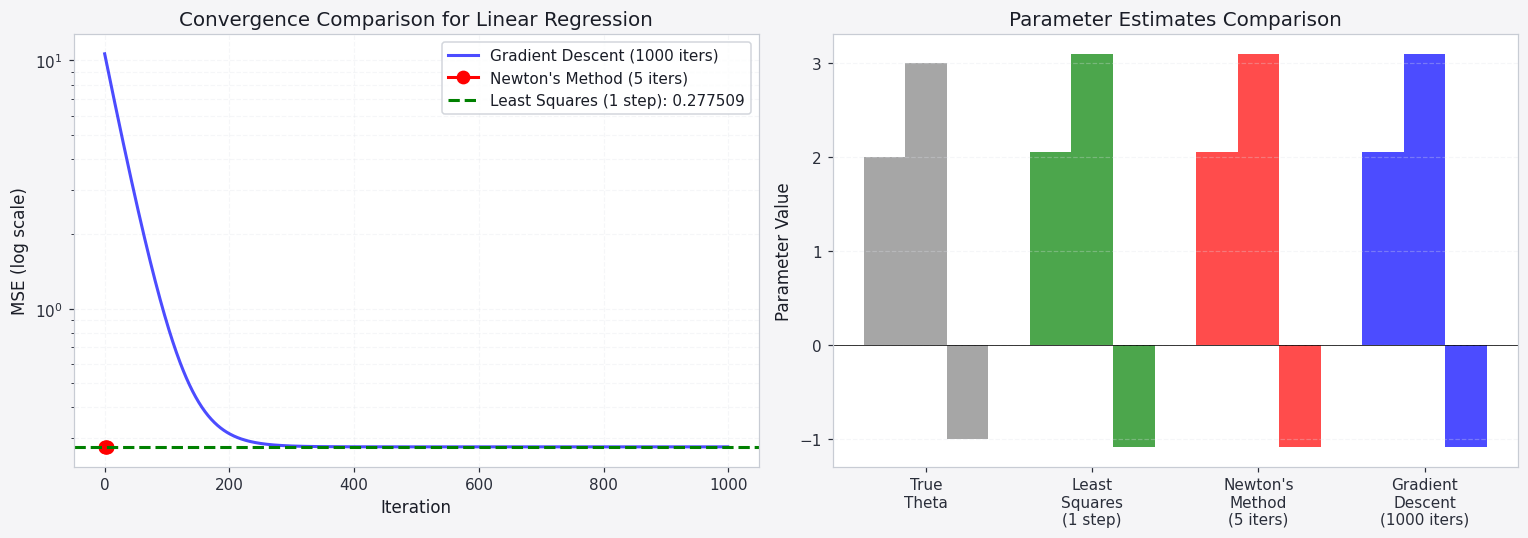


COMPARISON SUMMARY

True parameters:           [ 2  3 -1]
Least Squares (1 step):    [ 2.04639669  3.09536017 -1.08607105]
Newton's Method (5 iters): [ 2.04639669  3.09536017 -1.08607105]
Gradient Descent (1000):   [ 2.04639549  3.09535708 -1.08607067]

Final MSE:
  Least Squares:     0.2775086702
  Newton's Method:   0.2775086702
  Gradient Descent:  0.2775086702

Key Insight: All three methods find the same solution!
Least Squares is fastest (direct computation, no iterations)


In [3]:
# Compare three approaches to linear regression
np.random.seed(42)

# Generate synthetic data
n_samples = 100
X = np.random.randn(n_samples, 2)
# Add intercept
X = np.hstack([np.ones((n_samples, 1)), X])
theta_true = np.array([2, 3, -1])
y = X @ theta_true + np.random.randn(n_samples) * 0.5

# Method 1: Least Squares (Normal Equation)
theta_ls = np.linalg.inv(X.T @ X) @ X.T @ y
J_ls = np.mean((y - X @ theta_ls) ** 2)

# Method 2: Gradient Descent
theta_gd = np.zeros(3)
alpha = 0.01
history_gd = {"theta": [theta_gd.copy()], "J": []}
for _ in range(1000):
    grad = (2/n_samples) * X.T @ (X @ theta_gd - y)
    theta_gd = theta_gd - alpha * grad
    J_gd = np.mean((y - X @ theta_gd) ** 2)
    history_gd["J"].append(J_gd)
    history_gd["theta"].append(theta_gd.copy())

# Method 3: Newton's Method
theta_nm = np.zeros(3)
history_nm = {"theta": [theta_nm.copy()], "J": []}
# Newton converges very fast
for _ in range(5):
    grad = (2/n_samples) * X.T @ (X @ theta_nm - y)
    hess = (2/n_samples) * X.T @ X
    theta_nm = theta_nm - np.linalg.inv(hess) @ grad
    J_nm = np.mean((y - X @ theta_nm) ** 2)
    history_nm["J"].append(J_nm)
    history_nm["theta"].append(theta_nm.copy())

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Convergence curves
ax = axes[0]
ax.semilogy(history_gd["J"], "b-", linewidth=2, label="Gradient Descent (1000 iters)", alpha=0.7)
ax.semilogy(history_nm["J"], "ro-", linewidth=2, markersize=8, label="Newton's Method (5 iters)")
ax.axhline(J_ls, color="g", linestyle="--", linewidth=2, label=f"Least Squares (1 step): {J_ls:.6f}")
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Convergence Comparison for Linear Regression")
ax.legend()
ax.grid(alpha=0.3, which="both")

# Right: Parameter estimates comparison
ax = axes[1]
methods = ["True\nTheta", "Least\nSquares\n(1 step)", "Newton's\nMethod\n(5 iters)", "Gradient\nDescent\n(1000 iters)"]
theta_estimates = [theta_true, theta_ls, theta_nm, theta_gd]
x_pos = np.arange(len(methods))
colors = ["gray", "green", "red", "blue"]

for i, theta in enumerate(theta_estimates):
    ax.bar(x_pos[i] + np.array([-0.25, 0, 0.25]), theta, width=0.25, label=f"θ_{i+1}" if i == 0 else None, color=colors[i], alpha=0.7)

ax.set_ylabel("Parameter Value")
ax.set_title("Parameter Estimates Comparison")
ax.set_xticks(x_pos)
ax.set_xticklabels(methods)
ax.grid(alpha=0.3, axis="y")
ax.axhline(0, color="k", linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("COMPARISON SUMMARY")
print("="*70)
print(f"\nTrue parameters:           {theta_true}")
print(f"Least Squares (1 step):    {theta_ls}")
print(f"Newton's Method (5 iters): {theta_nm}")
print(f"Gradient Descent (1000):   {theta_gd}")
print(f"\nFinal MSE:")
print(f"  Least Squares:     {J_ls:.10f}")
print(f"  Newton's Method:   {np.mean((y - X @ theta_nm)**2):.10f}")
print(f"  Gradient Descent:  {np.mean((y - X @ theta_gd)**2):.10f}")
print(f"\nKey Insight: All three methods find the same solution!")
print(f"Least Squares is fastest (direct computation, no iterations)")


---

## Section 5: Connection to Probability and MLE

### 5.1 Gaussian Noise Model

Assume each observation has Gaussian noise:
$$y_i = \theta^T x_i + \epsilon_i \quad \text{where} \quad \epsilon_i \sim N(0, \sigma^2)$$

This means:
$$y_i | x_i \sim N(\theta^T x_i, \sigma^2)$$

Probability of single observation:
$$P(y_i | x_i; \theta) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - \theta^T x_i)^2}{2\sigma^2}\right)$$

### 5.2 MLE for Linear Regression

Likelihood for all data:
$$L(\theta | X, \mathbf{y}) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - \theta^T x_i)^2}{2\sigma^2}\right)$$

Log-likelihood:
$$\ell(\theta) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - \theta^T x_i)^2$$

Maximizing log-likelihood is equivalent to **minimizing the sum of squared errors**:
$$\max_\theta \ell(\theta) \iff \min_\theta \sum_{i=1}^{n}(y_i - \theta^T x_i)^2$$

**Key Result**: Under Gaussian noise assumption, **least squares is the Maximum Likelihood Estimator (MLE)** for linear regression!

---

## Section 6: Geometric Visualization

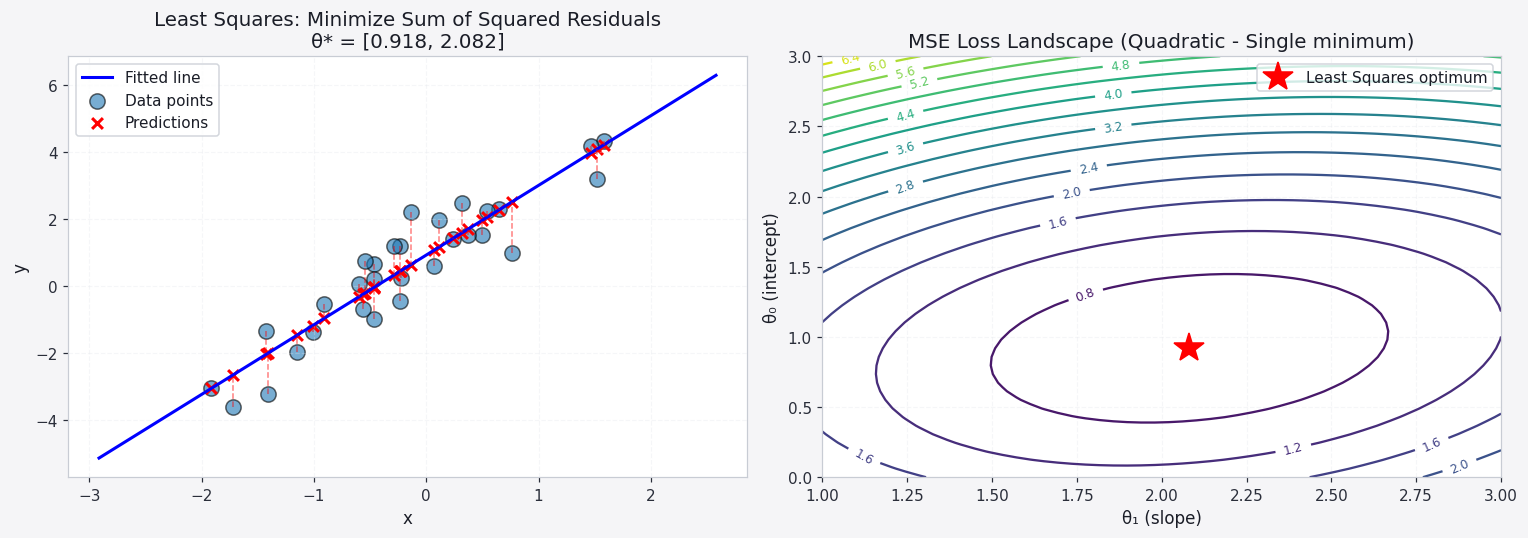


Key observations:
1. Loss landscape is perfectly quadratic (single global minimum)
2. Residuals shown as red dashed lines (perpendicular to fitted line)
3. Least squares finds parameters that minimize perpendicular distance
4. This is the orthogonal projection of y onto column space of X


In [4]:
# Geometric interpretation in 2D
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Residual plot (1D data)
np.random.seed(42)
x = np.random.randn(30)
y = 2*x + 1 + np.random.randn(30) * 0.8

# Fit line
X_line = np.vstack([np.ones(len(x)), x]).T
theta_fit = np.linalg.inv(X_line.T @ X_line) @ X_line.T @ y
y_pred = X_line @ theta_fit
residuals = y - y_pred

ax = axes[0]
x_range = np.linspace(x.min() - 1, x.max() + 1, 100)
y_line = theta_fit[0] + theta_fit[1] * x_range
ax.plot(x_range, y_line, "b-", linewidth=2, label="Fitted line")
ax.scatter(x, y, s=100, alpha=0.6, edgecolors="black", label="Data points")

# Draw residuals
for xi, yi, yp in zip(x, y, y_pred):
    ax.plot([xi, xi], [yi, yp], "r--", linewidth=1, alpha=0.5)
    
ax.scatter(x, y_pred, s=50, color="red", marker="x", linewidth=2, label="Predictions")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Least Squares: Minimize Sum of Squared Residuals\nθ* = [{theta_fit[0]:.3f}, {theta_fit[1]:.3f}]")
ax.legend()
ax.grid(alpha=0.3)

# Right: Loss landscape (2D)
# Simple 2D case with intercept and 1 feature
theta0_range = np.linspace(0, 3, 50)
theta1_range = np.linspace(1, 3, 50)
loss_grid = np.zeros((len(theta0_range), len(theta1_range)))

for i, t0 in enumerate(theta0_range):
    for j, t1 in enumerate(theta1_range):
        y_pred = t0 + t1 * x
        loss_grid[i, j] = np.mean((y - y_pred) ** 2)

ax = axes[1]
contour = ax.contour(theta1_range, theta0_range, loss_grid, levels=15, cmap="viridis")
ax.clabel(contour, inline=True, fontsize=8)
ax.plot(theta_fit[1], theta_fit[0], "r*", markersize=20, label="Least Squares optimum")
ax.set_xlabel("θ₁ (slope)")
ax.set_ylabel("θ₀ (intercept)")
ax.set_title("MSE Loss Landscape (Quadratic - Single minimum)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"1. Loss landscape is perfectly quadratic (single global minimum)")
print(f"2. Residuals shown as red dashed lines (perpendicular to fitted line)")
print(f"3. Least squares finds parameters that minimize perpendicular distance")
print(f"4. This is the orthogonal projection of y onto column space of X")

---

## Section 7: Practical Implementation and Properties

## Section 5: Gaussian Distribution and Its Relation to Least Squares

### 5.1 The Gaussian Noise Model

**Key Assumption**: Each observation consists of a true signal plus independent Gaussian noise:

$$y_i = \theta^T x_i + \epsilon_i \quad \text{where} \quad \epsilon_i \sim N(0, \sigma^2)$$

This means:
$$y_i | x_i; \theta \sim N(\theta^T x_i, \sigma^2)$$

**Interpretation**:
- True relationship: $\theta^T x_i$
- Observed $y_i$ deviates from truth by random Gaussian noise
- Noise is independent across samples
- Noise has constant variance $\sigma^2$ (homoscedastic)

### 5.2 Why Gaussian Distribution?

**Reasons Gaussian is ubiquitous**:

1. **Central Limit Theorem**: Many independent sources of noise combine to form Gaussian
2. **Mathematical convenience**: Gaussian likelihood has closed form
3. **Maximum entropy**: Among all distributions with fixed mean and variance, Gaussian has highest entropy
4. **Practical**: Empirically matches many real-world measurement errors

### 5.3 Probability Density Function

For a single observation:
$$P(y_i | x_i; \theta) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - \theta^T x_i)^2}{2\sigma^2}\right)$$

This is a **Gaussian distribution** centered at $\theta^T x_i$ with variance $\sigma^2$.

**Three equivalent forms**:

| Notation | Expression |
|----------|-----------|
| **PDF** | $\frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - \theta^T x_i)^2}{2\sigma^2}\right)$ |
| **Log-PDF** | $-\frac{1}{2}\log(2\pi\sigma^2) - \frac{(y_i - \theta^T x_i)^2}{2\sigma^2}$ |
| **Proportional to** | $\exp\left(-\frac{(y_i - \theta^T x_i)^2}{2\sigma^2}\right)$ |

---

### 5.4 From MLE to Least Squares

DERIVING LEAST SQUARES FROM GAUSSIAN MLE

1. LIKELIHOOD FOR SINGLE OBSERVATION
--------------------------------------------------------------------------------
   P(y_i | x_i; θ) = (1/√(2πσ²)) * exp(-(y_i - θ'x_i)² / (2σ²))

2. LOG-LIKELIHOOD FOR SINGLE OBSERVATION
--------------------------------------------------------------------------------
   ℓ_i(θ) = log P(y_i | x_i; θ)
          = -½ log(2πσ²) - (y_i - θ'x_i)² / (2σ²)
          = C - (y_i - θ'x_i)² / (2σ²)   [constant C doesn't affect optimization]

3. LOG-LIKELIHOOD FOR ALL DATA (i.i.d.)
--------------------------------------------------------------------------------
   ℓ(θ) = Σ_i ℓ_i(θ)
        = Σ_i [-½ log(2πσ²) - (y_i - θ'x_i)² / (2σ²)]
        = -n/2 * log(2πσ²) - (1/2σ²) * Σ_i (y_i - θ'x_i)²

4. MAXIMIZING LOG-LIKELIHOOD IS EQUIVALENT TO MINIMIZING SSE
--------------------------------------------------------------------------------
   max_θ ℓ(θ) ⟺ min_θ Σ_i (y_i - θ'x_i)²
   Why? The constant term -n/2*log(2πσ²) doesn't d

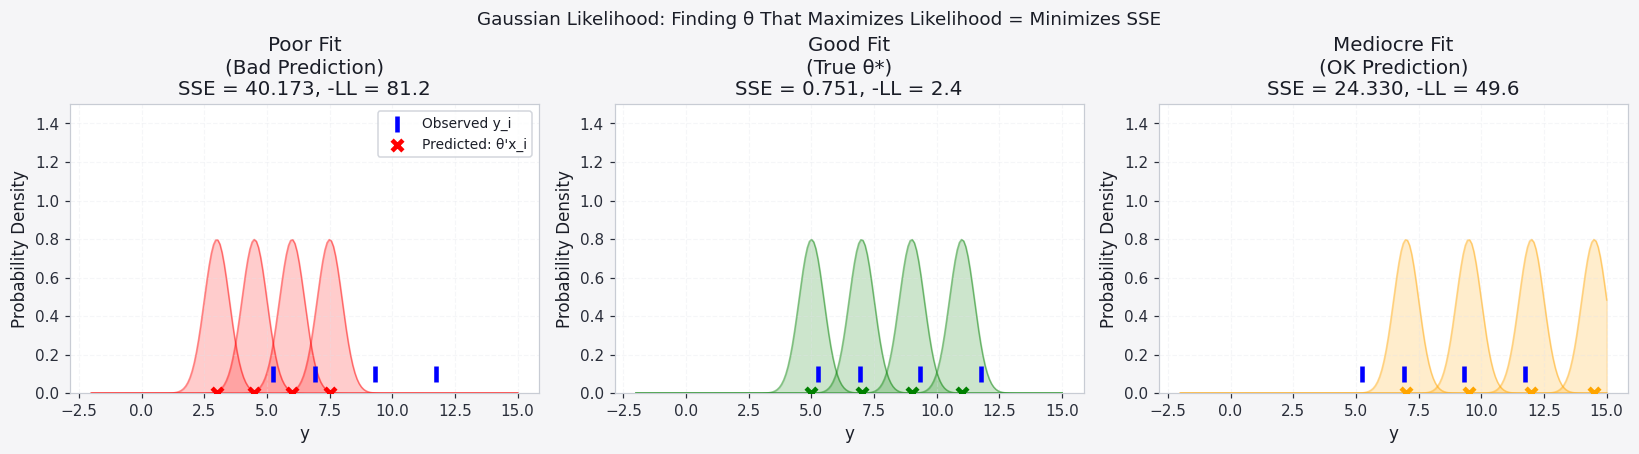


Observation: Good fit (green) has high likelihood values (tall Gaussians)
             Observations fall near predicted means


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Demonstration: Likelihood under Gaussian noise
print("="*80)
print("DERIVING LEAST SQUARES FROM GAUSSIAN MLE")
print("="*80)

print("\n1. LIKELIHOOD FOR SINGLE OBSERVATION")
print("-" * 80)
print("   P(y_i | x_i; θ) = (1/√(2πσ²)) * exp(-(y_i - θ'x_i)² / (2σ²))")

print("\n2. LOG-LIKELIHOOD FOR SINGLE OBSERVATION")
print("-" * 80)
print("   ℓ_i(θ) = log P(y_i | x_i; θ)")
print("          = -½ log(2πσ²) - (y_i - θ'x_i)² / (2σ²)")
print("          = C - (y_i - θ'x_i)² / (2σ²)   [constant C doesn't affect optimization]")

print("\n3. LOG-LIKELIHOOD FOR ALL DATA (i.i.d.)")
print("-" * 80)
print("   ℓ(θ) = Σ_i ℓ_i(θ)")
print("        = Σ_i [-½ log(2πσ²) - (y_i - θ'x_i)² / (2σ²)]")
print("        = -n/2 * log(2πσ²) - (1/2σ²) * Σ_i (y_i - θ'x_i)²")

print("\n4. MAXIMIZING LOG-LIKELIHOOD IS EQUIVALENT TO MINIMIZING SSE")
print("-" * 80)
print("   max_θ ℓ(θ) ⟺ min_θ Σ_i (y_i - θ'x_i)²")
print("   Why? The constant term -n/2*log(2πσ²) doesn't depend on θ")
print("        Maximizing ℓ(θ) = minimizing (1/2σ²)*SSE")
print("        Factor 1/(2σ²) is constant, so ignoring it doesn't change optimum")

print("\n5. MLE SOLUTION UNDER GAUSSIAN ASSUMPTION")
print("-" * 80)
print("   max_θ ℓ(θ) ⟹ min_θ SSE")
print("              ⟹ θ* = (X'X)⁻¹X'y")
print("   This is exactly the LEAST SQUARES SOLUTION!")

print("\n" + "="*80)
print("KEY INSIGHT: Under Gaussian noise, least squares = MLE")
print("="*80)

# Visualize Gaussian likelihood for different predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Data setup
np.random.seed(42)
X_simple = np.array([[1, 2], [1, 3], [1, 4], [1, 5]])
true_theta = np.array([1, 2])
y_obs = X_simple @ true_theta + np.random.randn(4) * 0.5

sigma_noise = 0.5
y_range = np.linspace(-2, 15, 200)

# Three different theta values
thetas_to_show = [
    # Poor fit
    np.array([0, 1.5]),
    # Good fit (true)
    np.array([1, 2.0]),
    # Mediocre fit
    np.array([2, 2.5]),
]
titles = ["Poor Fit\n(Bad Prediction)", "Good Fit\n(True θ*)", "Mediocre Fit\n(OK Prediction)"]
colors = ["red", "green", "orange"]

for idx, (ax, theta_test, title, color) in enumerate(zip(axes, thetas_to_show, titles, colors)):
    # Predicted values
    y_pred = X_simple @ theta_test
    
    # Compute likelihood for each observation
    likelihoods = [norm.pdf(y_range, loc=yp, scale=sigma_noise) for yp in y_pred]
    
    # Plot Gaussians
    for i, (yp, lik) in enumerate(zip(y_pred, likelihoods)):
        ax.plot(y_range, lik, color=color, alpha=0.4, linewidth=1)
        ax.fill_between(y_range, lik, alpha=0.2, color=color)
    
    # Mark observations
    ax.scatter(y_obs, [0.1]*len(y_obs), s=100, marker='|', color='blue', linewidth=3, label='Observed y_i', zorder=10)
    ax.scatter(y_pred, [0]*len(y_pred), s=50, marker='x', color=color, linewidth=3, label=f'Predicted: θ\'x_i', zorder=10)
    
    # Compute negative log-likelihood (SSE)
    sse = np.sum((y_obs - y_pred)**2)
    nll = -np.sum([norm.logpdf(y_obs[i], loc=y_pred[i], scale=sigma_noise) for i in range(len(y_obs))])
    
    ax.set_xlabel('y')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'{title}\nSSE = {sse:.3f}, -LL = {nll:.1f}')
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1.5])
    if idx == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Gaussian Likelihood: Finding θ That Maximizes Likelihood = Minimizes SSE', fontsize=12, y=1.02)
plt.show()

print("\nObservation: Good fit (green) has high likelihood values (tall Gaussians)")
print("             Observations fall near predicted means")


#### **Detailed Derivation**

**Step 1**: Write likelihood for all data (assuming i.i.d.):
$$L(\theta | X, \mathbf{y}) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - \theta^T x_i)^2}{2\sigma^2}\right)$$

**Step 2**: Compute log-likelihood:
$$\ell(\theta) = \log L(\theta | X, \mathbf{y}) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - \theta^T x_i)^2$$

**Step 3**: Identify maximization objective:
$$\max_\theta \ell(\theta) = \max_\theta \left[-\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(y_i - \theta^T x_i)^2\right]$$

The term $-\frac{n}{2}\log(2\pi\sigma^2)$ is **constant** (doesn't depend on $\theta$), so:

$$\max_\theta \ell(\theta) \iff \min_\theta \sum_{i=1}^{n}(y_i - \theta^T x_i)^2 = \min_\theta \text{SSE}(\theta)$$

**Step 4**: Solve for optimal parameters:
$$\boxed{\theta^*_{\text{MLE}} = (X^T X)^{-1}X^T \mathbf{y} = \theta^*_{\text{LS}}}$$

**Conclusion**: Under Gaussian noise assumption, **Maximum Likelihood Estimator (MLE) = Least Squares Solution**

---

### 5.5 Uncertainty Quantification: Estimating $\sigma^2$

The noise variance $\sigma^2$ can be estimated from residuals:

**Unbiased estimator**:
$$\hat{\sigma}^2 = \frac{1}{n-d}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 = \frac{\text{RSS}}{n-d}$$

where:
- RSS = Residual Sum of Squares = $\sum(y_i - \hat{y}_i)^2$
- $n$ = number of samples
- $d$ = number of parameters (degrees of freedom)
- $(n-d)$ = residual degrees of freedom

**Distribution of parameter estimates**:

Under Gaussian noise, the MLE $\hat{\theta}$ follows:
$$\hat{\theta} \sim N(\theta^*, \sigma^2(X^T X)^{-1})$$

This enables:
- **Confidence intervals** for parameters
- **Hypothesis testing** about parameter values
- **Uncertainty quantification** in predictions

---

### 5.6 Assumptions and Violations

#### **Gauss-Markov Assumptions** (for optimality):

| Assumption | Meaning | Violation Impact |
|-----------|---------|------------------|
| **Linearity** | True model is linear in parameters | Biased estimates |
| **Independence** | Observations are i.i.d. | Wrong confidence intervals |
| **Homoscedasticity** | Constant variance $\sigma^2$ | Inefficient estimates |
| **Exogeneity** | Features uncorrelated with noise | Biased estimates |
| **No multicollinearity** | Features linearly independent | Non-invertible $X^T X$ |

#### **What Happens When Assumptions Fail**:

| Violation | Consequence |
|-----------|------------|
| **Non-Gaussian noise** | Least squares still gives BLUE (best linear unbiased), but not MLE |
| **Heteroscedastic noise** | Least squares inefficient; use Weighted Least Squares (WLS) |
| **Correlated errors** | Violates i.i.d. assumption; use GLS or time-series methods |
| **Non-linear relationship** | Use non-linear regression, kernels, or neural networks |

---

### 5.7 Least Squares is Robust

**Good news**: Even if Gaussian assumption is violated:
- Least squares still gives **BLUE** (Best Linear Unbiased Estimator) by Gauss-Markov theorem
- Least squares remains **optimal** among all linear estimators
- Central Limit Theorem ensures approximate Gaussianity for $\hat{\theta}$ as $n \to \infty$
- Works well in practice even with non-Gaussian noise (e.g., t-distribution, mixture distributions)

**Bad news**: If assumption is violated:
- Confidence intervals and hypothesis tests may be inaccurate
- There may exist better non-linear estimators
- Standard errors may be underestimated (especially with heteroscedasticity)

---

### 5.8 Visualization: How Gaussian Noise Affects Estimates

HOW GAUSSIAN NOISE AFFECTS LEAST SQUARES ESTIMATES


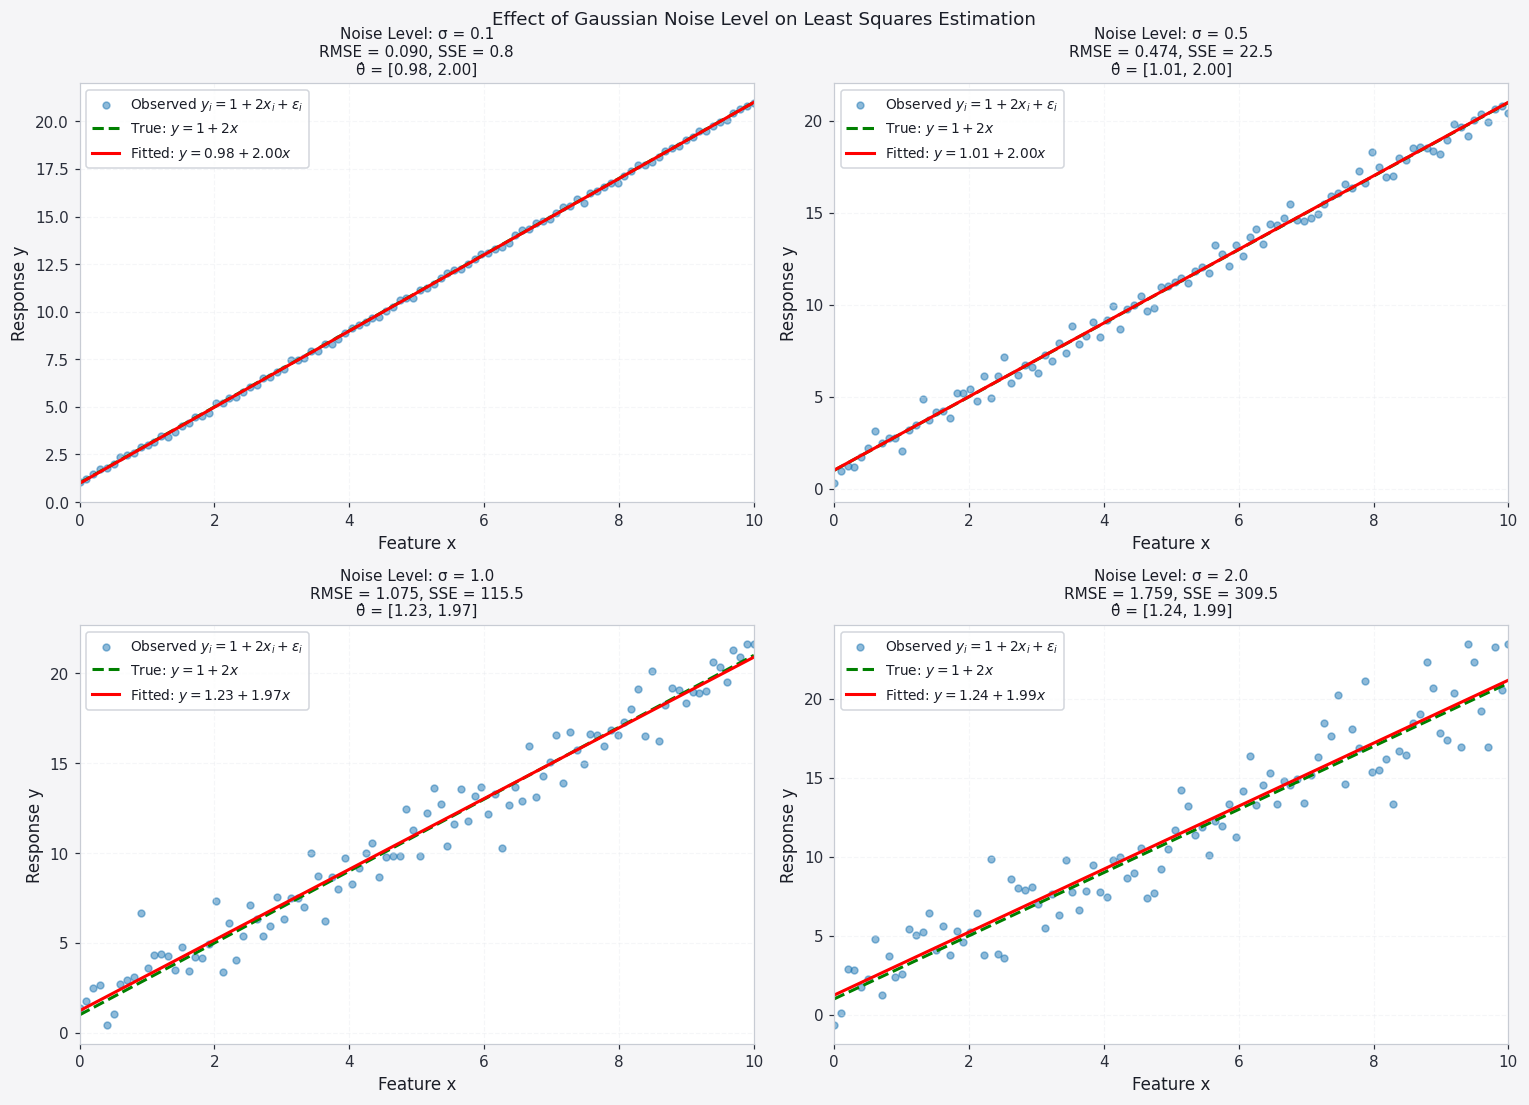


Observation 1: As noise increases, estimated parameters deviate from truth
Observation 2: Residuals (y_i - ŷ_i) become more dispersed (higher variance)
Observation 3: RMSE ≈ σ_noise (least squares learns noise level)

SAMPLING DISTRIBUTION OF LEAST SQUARES ESTIMATES


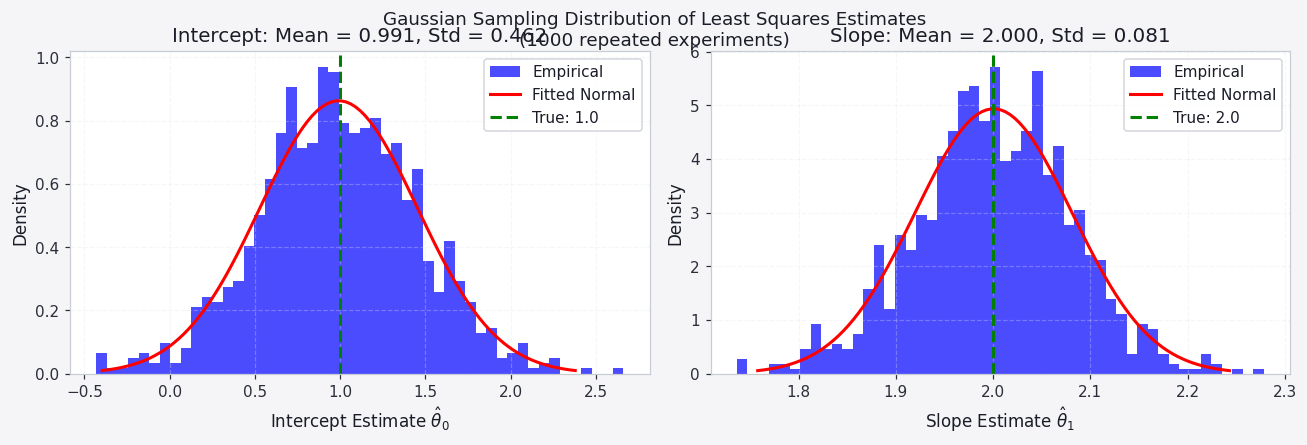


Intercept: True = 1.000, Mean Estimate = 0.991 (±0.462)
Slope:     True = 2.000, Mean Estimate = 2.000 (±0.081)

Key result: Estimates are unbiased (mean ≈ true value) and Gaussian distributed!
This confirms: θ̂ ~ N(θ*, σ²(X'X)⁻¹)


In [6]:
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Demonstrate effect of Gaussian noise on parameter estimation
np.random.seed(42)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# True parameters
true_slope = 2.0
true_intercept = 1.0
n_features = 1

print("="*80)
print("HOW GAUSSIAN NOISE AFFECTS LEAST SQUARES ESTIMATES")
print("="*80)

# Vary noise levels
noise_levels = [0.1, 0.5, 1.0, 2.0]

for idx, (ax, sigma_noise) in enumerate(zip(axes.flat, noise_levels)):
    # Generate data
    X_plot = np.linspace(0, 10, 100)
    X_with_intercept = np.column_stack([np.ones(len(X_plot)), X_plot])
    y_true = true_intercept + true_slope * X_plot
    
    # Add Gaussian noise
    y_observed = y_true + np.random.normal(0, sigma_noise, len(X_plot))
    
    # Fit least squares
    X_fit = np.column_stack([np.ones(len(X_plot)), X_plot])
    theta_hat = np.linalg.lstsq(X_fit, y_observed, rcond=None)[0]
    y_pred = X_fit @ theta_hat
    
    # Residuals
    residuals = y_observed - y_pred
    
    # Plot
    ax.scatter(X_plot, y_observed, alpha=0.5, s=20, label='Observed $y_i = 1 + 2x_i + ε_i$')
    ax.plot(X_plot, y_true, 'g--', linewidth=2, label='True: $y = 1 + 2x$')
    ax.plot(X_plot, y_pred, 'r-', linewidth=2, label=f'Fitted: $y = {theta_hat[0]:.2f} + {theta_hat[1]:.2f}x$')
    
    # Compute statistics
    sse = np.sum(residuals**2)
    rmse = np.sqrt(np.mean(residuals**2))
    
    ax.set_xlabel('Feature x')
    ax.set_ylabel('Response y')
    ax.set_title(f'Noise Level: σ = {sigma_noise}\nRMSE = {rmse:.3f}, SSE = {sse:.1f}\n' + 
                 f'θ̂ = [{theta_hat[0]:.2f}, {theta_hat[1]:.2f}]', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 10])

plt.tight_layout()
plt.suptitle('Effect of Gaussian Noise Level on Least Squares Estimation', fontsize=12, y=1.00)
plt.show()

print("\nObservation 1: As noise increases, estimated parameters deviate from truth")
print("Observation 2: Residuals (y_i - ŷ_i) become more dispersed (higher variance)")
print("Observation 3: RMSE ≈ σ_noise (least squares learns noise level)")

# Demonstrate sampling distribution of estimates
print("\n" + "="*80)
print("SAMPLING DISTRIBUTION OF LEAST SQUARES ESTIMATES")
print("="*80)

np.random.seed(42)

# Generate multiple datasets and fit models
n_samples = 20
n_experiments = 1000
sigma_noise = 1.0

theta_estimates = []
for _ in range(n_experiments):
    # Generate data
    X_exp = np.column_stack([np.ones(n_samples), np.random.uniform(0, 10, n_samples)])
    y_exp = X_exp @ np.array([true_intercept, true_slope]) + np.random.normal(0, sigma_noise, n_samples)
    
    # Fit
    theta_hat_exp = np.linalg.lstsq(X_exp, y_exp, rcond=None)[0]
    theta_estimates.append(theta_hat_exp)

theta_estimates = np.array(theta_estimates)

# Plot sampling distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Intercept
ax = axes[0]
ax.hist(theta_estimates[:, 0], bins=50, density=True, alpha=0.7, color='blue', label='Empirical')
mu_int = np.mean(theta_estimates[:, 0])
std_int = np.std(theta_estimates[:, 0])
x_range = np.linspace(mu_int - 3*std_int, mu_int + 3*std_int, 100)
ax.plot(x_range, norm.pdf(x_range, mu_int, std_int), 'r-', linewidth=2, label='Fitted Normal')
ax.axvline(true_intercept, color='green', linestyle='--', linewidth=2, label=f'True: {true_intercept}')
ax.set_xlabel('Intercept Estimate $\hat{θ}_0$')
ax.set_ylabel('Density')
ax.set_title(f'Intercept: Mean = {mu_int:.3f}, Std = {std_int:.3f}')
ax.legend()
ax.grid(alpha=0.3)

# Slope
ax = axes[1]
ax.hist(theta_estimates[:, 1], bins=50, density=True, alpha=0.7, color='blue', label='Empirical')
mu_slope = np.mean(theta_estimates[:, 1])
std_slope = np.std(theta_estimates[:, 1])
x_range = np.linspace(mu_slope - 3*std_slope, mu_slope + 3*std_slope, 100)
ax.plot(x_range, norm.pdf(x_range, mu_slope, std_slope), 'r-', linewidth=2, label='Fitted Normal')
ax.axvline(true_slope, color='green', linestyle='--', linewidth=2, label=f'True: {true_slope}')
ax.set_xlabel('Slope Estimate $\hat{θ}_1$')
ax.set_ylabel('Density')
ax.set_title(f'Slope: Mean = {mu_slope:.3f}, Std = {std_slope:.3f}')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Gaussian Sampling Distribution of Least Squares Estimates\n(1000 repeated experiments)', 
             fontsize=12, y=1.00)
plt.show()

print(f"\nIntercept: True = {true_intercept:.3f}, Mean Estimate = {mu_int:.3f} (±{std_int:.3f})")
print(f"Slope:     True = {true_slope:.3f}, Mean Estimate = {mu_slope:.3f} (±{std_slope:.3f})")
print(f"\nKey result: Estimates are unbiased (mean ≈ true value) and Gaussian distributed!")
print(f"This confirms: θ̂ ~ N(θ*, σ²(X'X)⁻¹)")


### 5.9 The Gauss-Markov Theorem

**Statement**: Under the following conditions:
1. Linear model: $y = X\theta + \epsilon$
2. Zero mean errors: $E[\epsilon] = 0$
3. Constant variance: $\text{Var}(\epsilon_i) = \sigma^2$ (homoscedasticity)
4. Independence: $\text{Cov}(\epsilon_i, \epsilon_j) = 0$ for $i \neq j$
5. Full rank: $X^T X$ is invertible

**Conclusion**: The least squares estimator $\hat{\theta} = (X^T X)^{-1}X^T y$ is the **BLUE**:
- **B**est: Minimum variance among all linear unbiased estimators
- **L**inear: $\hat{\theta} = A y$ for some matrix $A$
- **U**nbiased: $E[\hat{\theta}] = \theta^*$
- **E**stimator: Estimates $\theta^*$

**Note**: **No Gaussian assumption needed** for BLUE property!

---

### 5.10 Summary: Why Gaussian + Least Squares?

| Property | If Gaussian | Without Gaussian |
|----------|-----------|------------------|
| **MLE** | ✓ Least squares is MLE | ✗ Different estimator may be better |
| **BLUE** | ✓ (Gauss-Markov) | ✓ (Gauss-Markov) |
| **Efficiency** | ✓ Achieves Cramér-Rao bound | ✗ May not be efficient |
| **Distribution** | $\hat{\theta} \sim N(\theta^*, \sigma^2(X^T X)^{-1})$ | Approximately Gaussian (CLT) |
| **Inference** | ✓ Valid confidence intervals | Approximate for large $n$ |
| **Hypothesis tests** | ✓ Exact $t$-tests | Approximate |

---

### 5.11 Key Insight: Three Perspectives on Least Squares

| Perspective | View | Solution Form |
|-------------|------|---------------|
| **Algebraic** | Minimize residual norm | $(X^T X)^{-1}X^T y$ |
| **Geometric** | Project $y$ onto column space of $X$ | Orthogonal projection |
| **Probabilistic** | MLE under Gaussian noise | Gaussian likelihood maximization |

**All three perspectives lead to the same solution!** This unified view explains why least squares is so fundamental:
- It's elegant (single closed form)
- It's optimal under assumptions (MLE for Gaussian)
- It remains robust even without assumptions (BLUE via Gauss-Markov)
- It scales to many problems (regularization, kernels, GLMs)

---

### 5.12 Practical Recipe for Using Least Squares

**✓ Use least squares when:**
1. Problem is regression (predicting continuous values)
2. Linear or transformed-linear relationship suspected
3. Data fits in memory
4. Need interpretable coefficients and confidence intervals
5. Computational efficiency is important

**✗ Avoid least squares when:**
1. Outcome is discrete (classification) → Use logistic regression
2. Strong non-linear patterns → Use non-linear regression/kernels
3. Sparse solution needed → Use Lasso or other $L_1$ methods
4. Data is huge ($n > 10^6$, $d > 10^4$) → Use SGD or approximate methods
5. Outliers present → Use robust regression (e.g., Huber loss)
6. Heteroscedastic errors → Use Weighted Least Squares

---

## Section 6: Geometric Interpretation and Visualization

In [7]:
# Practical considerations for least squares

print("="*70)
print("PRACTICAL CONSIDERATIONS FOR LEAST SQUARES")
print("="*70)

print("\n1. NUMERICAL COMPUTATION")
print("-" * 70)
print("   Method A (Avoid): θ = (XᵀX)⁻¹Xᵀy")
print("     - Computing matrix inverse explicitly can be numerically unstable")
print("     - O(d³) cost for inversion")
print("\n   Method B (Better): Solve XᵀXθ = Xᵀy using Cholesky decomposition")
print("     - More stable: use np.linalg.solve(X.T @ X, X.T @ y)")
print("     - Same O(d³) cost but better numerical properties")
print("\n   Method C (Best): Use QR or SVD decomposition")
print("     - Most stable for ill-conditioned problems")
print("     - scipy.linalg.lstsq uses SVD internally")

print("\n2. MATRIX INVERTIBILITY CONDITIONS")
print("-" * 70)
print("   (XᵀX) is invertible if and only if:")
print("     - X has full column rank (rank(X) = d)")
print("     - No perfect multicollinearity among features")
print("\n   If rank(X) < d:")
print("     - Use pseudoinverse X⁺ = (XᵀX)⁻¹Xᵀ (via SVD)")
print("     - Solution exists but is not unique")

print("\n3. REGULARIZATION VARIANTS")
print("-" * 70)
print("   Ridge Regression (L2):")
print("     θ* = (XᵀX + λI)⁻¹Xᵀy")
print("     - Makes (XᵀX + λI) better conditioned")
print("\n   Lasso (L1):")
print("     min_θ ||y - Xθ||² + λ||θ||₁")
print("     - No closed form, use coordinate descent or proximal methods")
print("\n   Elastic Net (L1 + L2):")
print("     min_θ ||y - Xθ||² + λ₁||θ||₁ + λ₂||θ||²")
print("     - Combines benefits of Ridge and Lasso")

print("\n4. STATISTICAL PROPERTIES")
print("-" * 70)
print("   Under Gaussian noise assumption:")
print("     - θ̂ ~ N(θ*, σ²(XᵀX)⁻¹)")
print("     - θ̂ is the MLE (maximum likelihood estimator)")
print("     - θ̂ is BLUE (best linear unbiased estimator)")
print("     - θ̂ achieves Cramér-Rao lower bound")

print("\n5. COMPUTATIONAL COMPLEXITY")
print("-" * 70)
print("   Computing XᵀX:   O(nd²)")
print("   Computing Xᵀy:   O(nd)")
print("   Solving system:   O(d³)")
print("   Total:            O(nd² + d³)")
print("\n   For n >> d: dominated by O(nd²) term")
print("   For d >> n: dominated by O(d³) term")

print("\n" + "="*70)

PRACTICAL CONSIDERATIONS FOR LEAST SQUARES

1. NUMERICAL COMPUTATION
----------------------------------------------------------------------
   Method A (Avoid): θ = (XᵀX)⁻¹Xᵀy
     - Computing matrix inverse explicitly can be numerically unstable
     - O(d³) cost for inversion

   Method B (Better): Solve XᵀXθ = Xᵀy using Cholesky decomposition
     - More stable: use np.linalg.solve(X.T @ X, X.T @ y)
     - Same O(d³) cost but better numerical properties

   Method C (Best): Use QR or SVD decomposition
     - Most stable for ill-conditioned problems
     - scipy.linalg.lstsq uses SVD internally

2. MATRIX INVERTIBILITY CONDITIONS
----------------------------------------------------------------------
   (XᵀX) is invertible if and only if:
     - X has full column rank (rank(X) = d)
     - No perfect multicollinearity among features

   If rank(X) < d:
     - Use pseudoinverse X⁺ = (XᵀX)⁻¹Xᵀ (via SVD)
     - Solution exists but is not unique

3. REGULARIZATION VARIANTS
----------------

---

## Section 8: From Least Squares to Gradient Descent

### 8.1 When Least Squares Isn't Applicable

Least squares gives **closed-form solution** only when:
1. Loss is **quadratic** in parameters
2. Problem is **unconstrained**

For other problems:
- **Logistic regression**: Log-likelihood is non-quadratic (sigmoid) → No closed form
- **Neural networks**: Non-convex loss with many local minima → Need iterative methods
- **Constrained problems**: Bound constraints or L1 penalty → Use gradient descent or specialized solvers

### 8.2 Gradient Descent as Generalization

**Linear regression (Quadratic loss)**:
- Gradient descent converges in $O(1/\epsilon)$ iterations
- Least squares finds exact solution in 1 step

**Logistic regression (Log-likelihood loss)**:
- Least squares: Not applicable (non-quadratic)
- Gradient descent: Needed for iterative solution
- Newton's method: Faster convergence (quadratic locally)

**Neural networks (Complex non-convex loss)**:
- Least squares: Not applicable
- Gradient descent: Standard method (SGD variants)
- Newton's method: Too expensive (millions of parameters)

### 8.3 Why We Still Need Gradient Descent

- **Generality**: Works for any differentiable loss, not just quadratic
- **Scalability**: Can use mini-batches (SGD) for large datasets
- **Online learning**: Can update incrementally as new data arrives
- **Non-convex**: For neural networks where least squares doesn't apply

---

## Section 9: Connection to Other Concepts

### 9.1 Least Squares appears in:

| Concept | Connection |
|---------|------------|
| **Linear Regression** | Core: minimize MSE |
| **Normal Equation** | Closed-form solution for least squares |
| **Pseudoinverse** | Generalization of inverse using SVD |
| **Ridge Regression** | Regularized least squares (L2 penalty) |
| **Lasso** | Regularized least squares (L1 penalty) |
| **PCA** | Finds directions minimizing reconstruction error (least squares) |
| **Newton's Method** | For quadratic loss, converges in 1 step |
| **Gradient Descent** | General iterative method that least squares is special case of |
| **MLE** | For Gaussian noise, least squares = MLE |
| **Kernel Methods** | Can apply least squares in feature space |

---

## Section 10: Key Takeaways

### 10.1 Least Squares is:

✓ **Fundamental**: Foundation of linear regression and many ML methods  
✓ **Elegant**: Closed-form solution via normal equation  
✓ **Geometric**: Orthogonal projection onto column space of design matrix  
✓ **Optimal**: Under Gaussian noise, it's the MLE  
✓ **Efficient**: Single computation, no iterations or hyperparameters  
✓ **Interpretable**: Minimizes prediction error in original units  
✓ **Extensible**: Foundation for regularization, kernels, GLMs  

### 10.2 Least Squares vs Alternatives

| Aspect | Least Squares | Gradient Descent | Newton's Method |
|--------|---------------|------------------|------------------|
| **Applicability** | Linear/quadratic only | Any differentiable loss | Smooth, twice-differentiable |
| **Solution time** | 1 step (direct) | Many iterations | Few iterations |
| **Computational cost** | $O(nd² + d³)$ | $O(nd)$ per iter × iters | $O(d³)$ per iter × few iters |
| **Learning rate** | N/A | Must tune | Automatic (via Hessian) |
| **Scalability** | Medium | Excellent (mini-batch) | Poor (full Hessian) |
| **Non-convex** | N/A | Works but slow | May fail |

### 10.3 When to Use Least Squares

✓ **Do use** when:
- Problem is linear regression
- Data fits in memory
- Need exact solution
- Want interpretable coefficients
- Problem is well-conditioned

✗ **Don't use** when:
- Huge dimensions ($d > 10000$)
- Matrix is rank-deficient or ill-conditioned
- Need real-time online updates
- Data is non-linear or high-dimensional
- Using non-quadratic loss (logistic, neural networks)

---

## References

1. **Historical foundations:**
   - Stigler, S. M. (1981). *Gauss and the Invention of Least Squares*
   - Legendre, A. M. (1805). *Nouvelles méthodes pour la détermination des orbites des comètes*

2. **Statistical theory:**
   - Casella & Berger (2002). *Statistical Inference*. Chapter 5: Estimation
   - Linear regression is BLUE (Best Linear Unbiased Estimator) under Gauss-Markov assumptions

3. **Numerical computation:**
   - Golub & Van Loan (2013). *Matrix Computations* (4th ed.). Johns Hopkins University Press
   - Numerical stability of QR, Cholesky, and SVD decompositions

4. **Machine learning perspective:**
   - Boyd & Vandenberghe (2004). *Convex Optimization*. Chapter 4: Convex optimization problems
   - Hastie, Tibshirani & Friedman (2009). *Elements of Statistical Learning*. Chapter 3: Linear methods

5. **Extensions:**
   - Ridge regression, Lasso, and elastic net regularization
   - Generalized linear models (GLMs) extend least squares to non-Gaussian responses

---
## Practice Exercises

**Conceptual**

1. Derive the Normal Equation $\theta^* = (X^TX)^{-1}X^Ty$ from scratch by expanding $\|y - X\theta\|^2$, differentiating, and setting the gradient to zero. Show each algebraic step explicitly.

2. Prove that least squares is the MLE under Gaussian noise: starting from $y_i = \theta^Tx_i + \epsilon_i$ with $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$, write the log-likelihood for all $n$ observations and show that maximizing it is equivalent to minimizing $\|y - X\theta\|^2$.

3. The Gauss-Markov theorem states that the OLS estimator $\hat{\theta} = (X^TX)^{-1}X^Ty$ is BLUE (Best Linear Unbiased Estimator). "Best" means minimum variance. Suppose a rival estimator $\tilde{\theta} = Cy$ is linear and unbiased. Show that $\text{Var}(\tilde{\theta}) - \text{Var}(\hat{\theta})$ is positive semidefinite. (Hint: let $C = (X^TX)^{-1}X^T + D$ and show $D = 0$ minimizes variance.)

4. When $X$ has linearly dependent columns, $(X^TX)$ is singular and the Normal Equation has infinitely many solutions. Ridge regression modifies the objective to $\|y - X\theta\|^2 + \lambda\|\theta\|^2$ with $\lambda > 0$. Show that the ridge estimator $\hat{\theta}_\text{ridge} = (X^TX + \lambda I)^{-1}X^Ty$ always has a unique solution, even when $X^TX$ is singular.

5. For linear regression with 1D feature $x$ and response $y$, derive the closed-form expressions for slope $\hat{\beta}_1$ and intercept $\hat{\beta}_0$ directly (not via matrix notation). Show that $\hat{\beta}_1 = \text{Cov}(x, y) / \text{Var}(x)$. What does this formula say about when the slope is zero?

**Numerical**

6. Generate 100 samples from $y = 2x_1 + 3x_2 - x_3 + 1 + \epsilon$ with $\epsilon \sim \mathcal{N}(0, 0.5)$. Recover $\theta$ using three methods: (a) Normal Equation $(X^TX)^{-1}X^Ty$, (b) `np.linalg.solve(X.T @ X, X.T @ y)`, (c) `np.linalg.lstsq`. Compare numerical accuracy and timing. Use `np.linalg.cond(X.T @ X)` to check conditioning.

7. Create a multicollinear dataset where two features are nearly identical: $X_2 = X_1 + 0.001 \cdot \epsilon$. Fit OLS and ridge regression ($\lambda \in \{0, 0.01, 0.1, 1\}$) and compare: (a) condition number of $X^TX$, (b) coefficient estimates, (c) test MSE. Visualize how ridge stabilizes the coefficients.

8. Plot the loss landscape $J(\theta) = \|y - X\theta\|^2$ as a 2D contour (with 2 features, no intercept) and overlay the gradient descent path for 50 iterations. Annotate the Normal Equation solution as a star. Verify gradient descent converges to the same minimum.

**Reflection**

9. Least squares gives the **exact** minimum in one step for linear regression, while gradient descent takes many iterations to reach the same point. Yet virtually all modern large-scale ML uses gradient descent. When does the Normal Equation become impractical? Give specific thresholds for $n$ (samples) and $d$ (features) where gradient descent is preferred, and justify each.